In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df = df[['v1', 'v2']]

df.columns = ['label', 'text']

df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
class EmailFeatures(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        features = []

        for text in X:

            urls = re.findall(r'http[s]?://\S+', str(text))

            url_count = len(urls)

            suspicious_words = [
                'free',
                'winner',
                'urgent',
                'claim',
                'click',
                'prize',
                'verify',
                'bank',
                'password',
                'login'
            ]

            suspicious_count = sum(
                word in str(text).lower()
                for word in suspicious_words
            )

            digit_count = sum(c.isdigit() for c in str(text))

            text_length = len(str(text))

            features.append([
                url_count,
                suspicious_count,
                digit_count,
                text_length
            ])

        return np.array(features)

In [4]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

combined_features = FeatureUnion([
    ('tfidf', tfidf),
    ('email_features', EmailFeatures())
])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

In [6]:
X_train_features = combined_features.fit_transform(X_train)
X_test_features = combined_features.transform(X_test)

In [7]:
model = MultinomialNB()

model.fit(X_train_features, y_train)

print("Model Training Completed!")

Model Training Completed!


In [8]:
y_pred = model.predict(X_test_features)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 97.58%

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.91      0.91       150

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



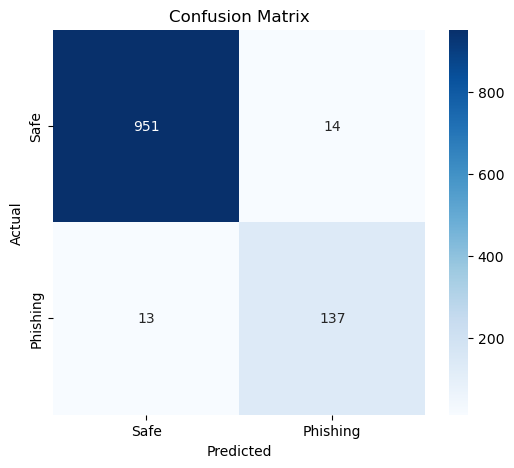

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Safe', 'Phishing'],
    yticklabels=['Safe', 'Phishing']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [10]:
sample_email = """
URGENT!

Your bank account has been suspended.

Click here immediately:
http://fakebank-login.com
"""

sample_features = combined_features.transform([sample_email])

prediction = model.predict(sample_features)

if prediction[0] == 1:
    print("⚠️ PHISHING/SPAM EMAIL")
else:
    print("✅ SAFE EMAIL")

⚠️ PHISHING/SPAM EMAIL
